<a href="https://colab.research.google.com/github/jaxa4ever-code/week-5/blob/main/lr_numpy_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression using Numpy and Sklearn

**Machine Learning Course**

We'll implement **logistic regression** using only NumPy to predict whether a student **passed** or **failed** an exam based on **hours studied**. Every step is explained and visualized so you can see how the model learns.

## 1. The Data

We have **10 students**: for each we know **hours studied** and **outcome** (0 = Failed, 1 = Passed).

| Student | Hours Studied | Passed (0/1) |
|---------|----------------|-------------|
| 1       | 0.5            | 0           |
| 2       | 1.0            | 0           |
| 3       | 1.5            | 0           |
| 4       | 2.0            | 0           |
| 5       | 2.5            | 0           |
| 6       | 3.0            | 1           |
| 7       | 3.5            | 1           |
| 8       | 4.0            | 1           |
| 9       | 4.5            | 1           |
| 10      | 5.0            | 1           |

Goal: learn a **decision boundary** so we can predict pass/fail for new hours.

### Load data and visualize

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- FEATURES: hours studied (one feature per sample) ---
# Shape: (10,) = 10 samples, 1 feature (we'll add a column of 1s for the bias)
hours = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0], dtype=np.float64)

# --- LABELS: 0 = Failed, 1 = Passed ---
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=np.float64)

# Reshape to column vectors for matrix math: (10, 1)
y = y.reshape(-1, 1)

# Design matrix X: add a column of 1s (bias term) so we have [1, hours]
# Shape: (10, 2) — each row is [1, hours_studied]
X = np.column_stack([np.ones_like(hours), hours])

print("X (bias + hours):")
print(X)
print("\ny (0=Fail, 1=Pass):")
print(y)
print("Shapes: X", X.shape, ", y", y.shape)

In [ ]:
# --- VISUALIZATION: scatter plot of data ---
plt.figure(figsize=(8, 5))
# Failed (y=0) in red, Passed (y=1) in green
plt.scatter(hours[y.ravel() == 0], y[y.ravel() == 0], color='red', s=80, label='Failed', edgecolors='black')
plt.scatter(hours[y.ravel() == 1], y[y.ravel() == 1], color='green', s=80, label='Passed', edgecolors='black')
plt.xlabel('Hours Studied')
plt.ylabel('Passed (0 or 1)')
plt.title('Training Data: Hours Studied vs Pass/Fail')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yticks([0, 1], ['Failed', 'Passed'])
plt.tight_layout()
plt.show()

We want a **smooth curve** (probability of passing) between 0 and 1, not a hard step. That curve is given by the **sigmoid** function.

## 2. Sigmoid Function

Logistic regression models **probability** that $y=1$ (passed) as:

$$P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z = w_0 + w_1 \cdot \text{hours}$ (linear combination of weights and features).

- $\sigma(z)$ is always between **0** and **1**.
- When $z$ is large and positive, $\sigma(z) \to 1$ (likely pass).
- When $z$ is large and negative, $\sigma(z) \to 0$ (likely fail).

In [ ]:
def sigmoid(z):
    """
    Sigmoid: 1 / (1 + exp(-z)).
    Input z can be a scalar or array; output has same shape, values in (0, 1).
    """
    # Clip z to avoid overflow in exp(-z) for very negative z
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

# Quick check: sigmoid(0) = 0.5
print("sigmoid(0) =", sigmoid(0))
print("sigmoid(5) ≈ 1:", sigmoid(5))
print("sigmoid(-5) ≈ 0:", sigmoid(-5))

In [ ]:
# --- VISUALIZATION: sigmoid curve ---
z_plot = np.linspace(-6, 6, 200)
plt.figure(figsize=(8, 4))
plt.plot(z_plot, sigmoid(z_plot), 'b-', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.xlabel('z (linear combination)')
plt.ylabel('σ(z) = P(y=1)')
plt.title('Sigmoid: maps any z to a probability in (0, 1)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Model: Forward Pass (Prediction)

For weights $\mathbf{w} = [w_0, w_1]$ (bias and coefficient for hours):

1. **Linear part:** $z = X \mathbf{w}$ (matrix-vector product; one z per sample).
2. **Probability:** $\hat{p} = \sigma(z)$ = probability of passing.

We predict **class 1 (pass)** if $\hat{p} \geq 0.5$, else **class 0 (fail)**.

In [ ]:
def forward(X, w):
    """
    Forward pass: compute P(y=1) for each sample.
    X: (n_samples, 2) — each row [1, hours]
    w: (2, 1) — [w_bias, w_hours]
    Returns: p_hat (n_samples, 1), values in (0, 1)
    """
    z = X @ w          # (n, 2) @ (2, 1) -> (n, 1)
    p_hat = sigmoid(z) # apply sigmoid element-wise
    return p_hat

## 4. Loss Function: Binary Cross-Entropy

We measure how wrong our probabilities $\hat{p}$ are using **binary cross-entropy** (log loss):

$$J(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i) \right]$$

- If $y_i=1$ we want $\hat{p}_i$ close to 1 (small $\log(\hat{p}_i)$ penalty when wrong).
- If $y_i=0$ we want $\hat{p}_i$ close to 0 (small $\log(1-\hat{p}_i)$ penalty when wrong).
- We minimize $J$ by updating $\mathbf{w}$.

In [ ]:
def binary_cross_entropy(y, p_hat, eps=1e-15):
    """
    Binary cross-entropy loss (average over samples).
    y: (n, 1) true labels 0 or 1
    p_hat: (n, 1) predicted probabilities
    eps: small constant to avoid log(0)
    """
    p_hat = np.clip(p_hat, eps, 1 - eps)
    n = y.shape[0]
    # J = - (1/n) * sum_i [ y_i*log(p_i) + (1-y_i)*log(1-p_i) ]
    loss = -np.mean(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))
    return loss

## 5. Gradients and Gradient Descent

The gradient of $J$ with respect to $\mathbf{w}$ is:

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{n} X^T (\hat{p} - y)$$

So we update: $\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \frac{\partial J}{\partial \mathbf{w}}$ where $\alpha$ is the **learning rate**.

In [ ]:
def gradient(X, y, p_hat):
    """
    Gradient of binary cross-entropy w.r.t. w.
    dJ/dw = (1/n) * X^T @ (p_hat - y)
    Returns: shape (2, 1), same as w
    """
    n = X.shape[0]
    error = p_hat - y   # (n, 1)
    grad = (X.T @ error) / n   # (2, n) @ (n, 1) -> (2, 1)
    return grad

## 6. Training Loop

Repeat for many **epochs**:
1. Forward: compute $\hat{p}$.
2. Loss: compute $J$.
3. Backward: compute gradient.
4. Update: $\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \text{gradient}$.

In [ ]:
np.random.seed(42)

# --- HYPERPARAMETERS ---
n_features = X.shape[1]   # 2 (bias + hours)
learning_rate = 0.5       # step size for weight updates (α)
epochs = 500              # number of full passes over the data

# --- INITIALIZE WEIGHTS: small random values (w[0]=bias, w[1]=coef for hours) ---
w = np.random.randn(n_features, 1) * 0.1

# --- Store loss per epoch for plotting ---
loss_history = []

for epoch in range(epochs):
    # 1. Forward pass: predicted probabilities
    p_hat = forward(X, w)

    # 2. Compute loss (binary cross-entropy)
    loss = binary_cross_entropy(y, p_hat)
    loss_history.append(loss)

    # 3. Gradient w.r.t. w
    grad = gradient(X, y, p_hat)

    # 4. Update weights: gradient descent
    w = w - learning_rate * grad

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} — Loss: {loss:.4f}")

print("\nFinal weights:")
print("w_bias (intercept):", w[0, 0])
print("w_hours (slope):", w[1, 0])

In [ ]:
# --- VISUALIZATION: loss over epochs ---
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='darkblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training: Loss decreases as the model learns')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Decision Boundary and Probability Curve

The **decision boundary** is where $z = w_0 + w_1 \cdot \text{hours} = 0$, i.e. $P(y=1) = 0.5$.

Solving: $\text{hours}_{\text{boundary}} = -w_0 / w_1$.

We can plot the **sigmoid curve** over hours (probability of pass vs hours) and the data points.

In [ ]:
# --- Decision boundary: where z = 0 ---
# z = w[0] + w[1]*hours = 0  =>  hours = -w[0]/w[1]
boundary_hours = -w[0, 0] / w[1, 0]
print(f"Decision boundary: P(pass)=0.5 at {boundary_hours:.2f} hours")

# --- Probability curve: P(pass) vs hours ---
hours_curve = np.linspace(0, 6, 200)
X_curve = np.column_stack([np.ones_like(hours_curve), hours_curve])
p_curve = forward(X_curve, w)

plt.figure(figsize=(9, 5))
# Data points
plt.scatter(hours[y.ravel() == 0], y[y.ravel() == 0], color='red', s=80, label='Failed', edgecolors='black', zorder=2)
plt.scatter(hours[y.ravel() == 1], y[y.ravel() == 1], color='green', s=80, label='Passed', edgecolors='black', zorder=2)
# Probability curve
plt.plot(hours_curve, p_curve, 'b-', linewidth=2, label='P(Pass)')
# Decision boundary (vertical line at 0.5 probability)
plt.axvline(boundary_hours, color='gray', linestyle='--', alpha=0.8, label=f'Decision boundary ({boundary_hours:.2f} h)')
plt.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Hours Studied')
plt.ylabel('P(Pass) / Label')
plt.title('Logistic Regression: Learned P(Pass) vs Hours Studied')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yticks([0, 0.5, 1], ['0 (Fail)', '0.5', '1 (Pass)'])
plt.tight_layout()
plt.show()

## 8. Predictions on Training Data

Predict **class** by thresholding: $\hat{y} = 1$ if $\hat{p} \geq 0.5$, else $0$.

In [ ]:
def predict_class(X, w, threshold=0.5):
    """Predict 0 or 1 using threshold on probability."""
    p_hat = forward(X, w)
    return (p_hat >= threshold).astype(np.float64)

y_pred = predict_class(X, w)

print("Hours | True | Predicted | P(Pass)")
print("-" * 40)
p_hat = forward(X, w)
for i in range(len(hours)):
    print(f"{hours[i]:5.1f} | {int(y[i,0]):4d} | {int(y_pred[i,0]):9d} | {p_hat[i,0]:.3f}")

accuracy = np.mean(y_pred == y)
print(f"\nTraining accuracy: {accuracy*100:.0f}%")

## 9. Predict for New Students

Use the learned $\mathbf{w}$ to predict pass/fail for any number of hours.

In [ ]:
def predict_hours(hours_new, w):
    """Predict probability and class for one or more hours."""
    hours_new = np.atleast_1d(hours_new)
    X_new = np.column_stack([np.ones_like(hours_new), hours_new])
    p = forward(X_new, w)
    y_pred = (p >= 0.5).astype(np.float64)
    return p, y_pred

# Example: 2.2 hours and 4.2 hours
for h in [2.2, 4.2]:
    p, pred = predict_hours(h, w)
    outcome = "Pass" if pred[0, 0] == 1 else "Fail"
    print(f"{h} hours → P(Pass) = {p[0,0]:.3f} → Predict: {outcome}")

---
**Summary**
- **Data:** 10 samples (hours studied, pass/fail).
- **Model:** $P(\text{pass}) = \sigma(w_0 + w_1 \cdot \text{hours})$.
- **Loss:** Binary cross-entropy; minimized with gradient descent.
- **Output:** Probabilities and class predictions; decision boundary at $P=0.5$.

---
# Exercise 1 (70%): Logistic Regression with Multiple Features

**Your turn.** Use the same ideas as above, but now we have **3 features** per student and **15 samples**. Implement every step yourself in the cells below — replace each `# TODO` with your code.

**Data:** Each student has:
- **hours_studied** (e.g. 1.2, 3.5, …)
- **hours_slept** (e.g. 5, 7, …)
- **attendance** (fraction of classes attended, 0–1)

**Label:** `passed` = 1 if they passed the exam, 0 otherwise.

**Goal:** Build the design matrix \(X\), implement sigmoid, forward pass, loss, gradient, training loop, and prediction. Then report training accuracy.

## Exercise data (15 students)

| hours_studied | hours_slept | attendance | passed |
|---------------|-------------|------------|--------|
| 1.2 | 5 | 0.6 | 0 |
| 1.5 | 6 | 0.7 | 0 |
| 2.0 | 5.5 | 0.5 | 0 |
| 2.2 | 6.5 | 0.8 | 0 |
| 2.8 | 7 | 0.6 | 0 |
| 3.0 | 6 | 0.9 | 1 |
| 3.2 | 7.5 | 0.7 | 1 |
| 3.5 | 7 | 0.85 | 1 |
| 4.0 | 8 | 0.9 | 1 |
| 4.2 | 7 | 0.95 | 1 |
| 4.5 | 8 | 0.8 | 1 |
| 4.8 | 7.5 | 0.9 | 1 |
| 5.0 | 8 | 1.0 | 1 |
| 5.2 | 6.5 | 0.75 | 1 |
| 5.5 | 8 | 0.95 | 1 |

Use the arrays below; your job is to build **X** (with a bias column) and **y**.

In [71]:
import numpy as np

# Raw features (15 samples, 3 features each)
hours_studied = np.array([1.2, 1.5, 2.0, 2.2, 2.8, 3.0, 3.2, 3.5, 4.0, 4.2, 4.5, 4.8, 5.0, 5.2, 5.5], dtype=np.float64)
hours_slept   = np.array([5.0, 6.0, 5.5, 6.5, 7.0, 6.0, 7.5, 7.0, 8.0, 7.0, 8.0, 7.5, 8.0, 6.5, 8.0], dtype=np.float64)
attendance    = np.array([0.6, 0.7, 0.5, 0.8, 0.6, 0.9, 0.7, 0.85, 0.9, 0.95, 0.8, 0.9, 1.0, 0.75, 0.95], dtype=np.float64)

# Labels: 0 = failed, 1 = passed
passed = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float64)

# TODO: Build design matrix X with shape (15, 4): column of 1s (bias) + hours_studied + hours_slept + attendance
# Hint: use np.column_stack([np.ones(...), hours_studied, hours_slept, attendance])
X = np.column_stack([np.ones_like(hours_studied), hours_studied, hours_slept, attendance])

# TODO: Reshape passed into column vector y with shape (15, 1)
y = passed.reshape(-1, 1)

# Sanity check (uncomment after you implement):
print("X shape:", X.shape, "  y shape:", y.shape)


print("X (bias + hours_studied + hours_slept + attendance):")
print(X)
print("\ny (0=Fail, 1=Pass):")
print(y)
print("Shapes: X", X.shape, ", y", y.shape)

X shape: (15, 4)   y shape: (15, 1)
X (bias + hours_studied + hours_slept + attendance):
[[1.   1.2  5.   0.6 ]
 [1.   1.5  6.   0.7 ]
 [1.   2.   5.5  0.5 ]
 [1.   2.2  6.5  0.8 ]
 [1.   2.8  7.   0.6 ]
 [1.   3.   6.   0.9 ]
 [1.   3.2  7.5  0.7 ]
 [1.   3.5  7.   0.85]
 [1.   4.   8.   0.9 ]
 [1.   4.2  7.   0.95]
 [1.   4.5  8.   0.8 ]
 [1.   4.8  7.5  0.9 ]
 [1.   5.   8.   1.  ]
 [1.   5.2  6.5  0.75]
 [1.   5.5  8.   0.95]]

y (0=Fail, 1=Pass):
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]
Shapes: X (15, 4) , y (15, 1)


In [77]:
# TODO: Implement sigmoid(z) = 1 / (1 + exp(-z)). Clip z to avoid overflow (e.g. between -500 and 500).
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

# Quick check: sigmoid(0) = 0.5
print("sigmoid(0) =", sigmoid(0))
print("sigmoid(5) ≈ 1:", sigmoid(5))
print("sigmoid(-5) ≈ 0:", sigmoid(-5))

sigmoid(0) = 0.5
sigmoid(5) ≈ 1: 0.9933071490757153
sigmoid(-5) ≈ 0: 0.0066928509242848554


In [78]:
# TODO: Forward pass. Compute z = X @ w, then p_hat = sigmoid(z). Return p_hat (same shape as z).
def forward(X, w):
    z = X @ w
    p_hat = sigmoid(z)
    return p_hat

In [66]:
# TODO: Binary cross-entropy loss. J = -mean( y*log(p_hat) + (1-y)*log(1-p_hat) ).
# Clip p_hat to [eps, 1-eps] to avoid log(0). Use eps=1e-15.
def binary_cross_entropy(y, p_hat, eps=1e-15):
    p_hat = np.clip(p_hat, eps, 1 - eps)
    loss = -np.mean(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))
    return loss

In [69]:
# TODO: Gradient of loss w.r.t. w. grad = (1/n) * X.T @ (p_hat - y). Return shape (4, 1).
def gradient(X, y, p_hat):
    n = X.shape[0]
    error = p_hat - y   # (n, 1)
    grad = (X.T @ error) / n   # (n_features, n) @ (n, 1) -> (n_features, 1)
    return grad

### Training loop (gradient descent)
Fill in the TODOs: hyperparameters, weight init, and inside the loop — forward, loss, gradient, weight update.

In [79]:
import numpy as np

# Set seed
np.random.seed(42)

# Hyperparameters
learning_rate = 0.1
epochs = 1000

# Number of features
n_features = X.shape[1]

# Initialize weights correctly based on number of features
w = np.random.randn(n_features, 1) * 0.1

loss_history = []

for epoch in range(epochs):

    # Forward pass
    p_hat = forward(X, w)

    # Compute loss
    loss = binary_cross_entropy(y, p_hat)
    loss_history.append(loss)

    # Compute gradient
    grad = gradient(X, y, p_hat)

    # Update weights
    w -= learning_rate * grad

    # Print progress
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 200, Loss: 0.1884
Epoch 400, Loss: 0.1404
Epoch 600, Loss: 0.1189
Epoch 800, Loss: 0.1060
Epoch 1000, Loss: 0.0971


### Evaluation
Predict class (0/1) for all training samples and compute accuracy.

In [80]:
# TODO: Get predicted probabilities with forward(X, w), then threshold at 0.5 to get class (0 or 1)
# TODO: accuracy = fraction of samples where y_pred equals y (use np.mean(y_pred == y))
p_hat = forward(X, w)
y_pred = (p_hat >= 0.5).astype(np.float64)
accuracy = np.mean(y_pred == y)
print("Training accuracy:", accuracy)

Training accuracy: 1.0


In [81]:
# TODO: Predict for a new student: hours_studied=3.8, hours_slept=7, attendance=0.88
# Build row [1, 3.8, 7, 0.88], call forward(..., w), then print P(pass) and Pass/Fail
new_student = np.array([[1, 3.8, 7, 0.88]])

p = forward(new_student, w)   # Call forward pass

print("P(pass) =", p[0,0], "->", "Pass" if p[0,0] >= 0.5 else "Fail")

P(pass) = 0.98522498199886 -> Pass


---
# Logistic Regression with scikit-learn

We now solve the **same problem** as in the first part (10 students, **study hours only**, pass/fail) using the **scikit-learn** library. This is the standard way to run logistic regression in practice — no need to implement gradient descent by hand.

## Same data as before: 10 samples, one feature (hours studied)


In [82]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Same 10-sample data from the NumPy section: hours studied and pass/fail
hours = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0], dtype=np.float64)
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=np.int64)

# scikit-learn expects X as a 2D array: (n_samples, n_features). Reshape hours to (10, 1).
X = hours.reshape(-1, 1)

print("X (hours studied, one column):", X.shape)
print("y (0=Fail, 1=Pass):", y.shape)

X (hours studied, one column): (10, 1)
y (0=Fail, 1=Pass): (10,)


In [83]:
# Create the model. fit_intercept=True adds the bias term (like our column of 1s in NumPy).
model = LogisticRegression(fit_intercept=True, random_state=42)

# Fit: learns weights (coefficient for hours + intercept) from X, y
model.fit(X, y)

# Predict class (0 or 1) for training data
y_pred = model.predict(X)

# Predict probabilities P(y=1) for each sample
y_proba = model.predict_proba(X)[:, 1]  # second column is P(pass)

print("Predictions:", y_pred)
print("P(pass):    ", np.round(y_proba, 3))
print("Training accuracy:", (y_pred == y).mean())

Predictions: [0 0 0 0 0 1 1 1 1 1]
P(pass):     [0.04  0.078 0.146 0.258 0.413 0.587 0.742 0.854 0.922 0.96 ]
Training accuracy: 1.0


In [84]:
# Learned parameters (compare with our NumPy w: intercept ≈ w0, coef ≈ w1)
print("Intercept (bias):", model.intercept_[0])
print("Coefficient (hours):", model.coef_[0, 0])
# Decision boundary: P(pass)=0.5 when  intercept + coef * hours = 0  =>  hours = -intercept/coef
boundary = -model.intercept_[0] / model.coef_[0, 0]
print("Decision boundary (hours):", round(boundary, 2))

Intercept (bias): -3.8822491027277857
Coefficient (hours): 1.411732620979249
Decision boundary (hours): 2.75


In [85]:
# Predict for new students (e.g. 2.2 and 4.2 hours)
X_new = np.array([[2.2], [4.2]])
pred_new = model.predict(X_new)
proba_new = model.predict_proba(X_new)[:, 1]
for hrs, p, prob in zip(X_new.ravel(), pred_new, proba_new):
    print(f"{hrs} hours → P(pass) = {prob:.3f} → {'Pass' if p == 1 else 'Fail'}")

2.2 hours → P(pass) = 0.315 → Fail
4.2 hours → P(pass) = 0.886 → Pass


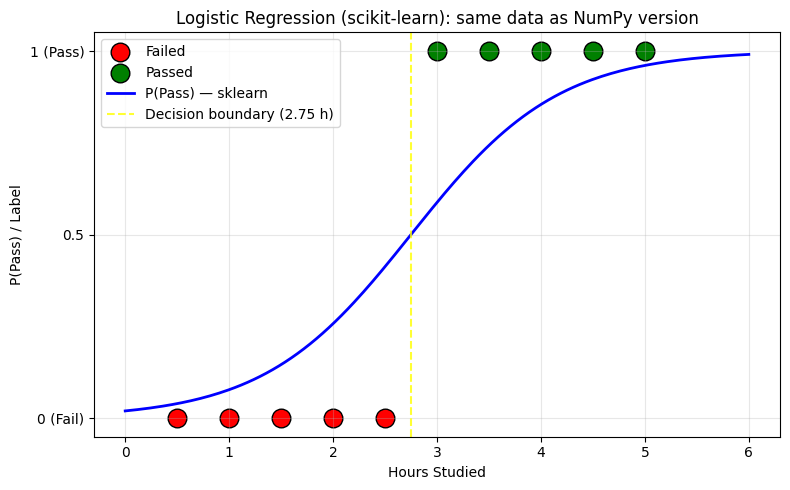

In [95]:
# Visualize: data points + sklearn's probability curve (same idea as our NumPy plot)
import matplotlib.pyplot as plt

hours_curve = np.linspace(0, 6, 200).reshape(-1, 1)
p_curve = model.predict_proba(hours_curve)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(hours[y == 0], y[y == 0], color='red', s=180, label='Failed', edgecolors='black')
plt.scatter(hours[y == 1], y[y == 1], color='green', s=180, label='Passed', edgecolors='black')
plt.plot(hours_curve, p_curve, 'b-', linewidth=2, label='P(Pass) — sklearn')
plt.axvline(boundary, color='yellow', linestyle='--', alpha=0.8, label=f'Decision boundary ({boundary:.2f} h)')
plt.xlabel('Hours Studied')
plt.ylabel('P(Pass) / Label')
plt.title('Logistic Regression (scikit-learn): same data as NumPy version')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yticks([0, 0.5, 1], ['0 (Fail)', '0.5', '1 (Pass)'])
plt.tight_layout()
plt.show()

---
# Exercise 2 (30%): Same problem with scikit-learn

**Your turn.** Use the **same 15-student dataset** (hours_studied, hours_slept, attendance → pass/fail) from the NumPy exercise above, but this time implement logistic regression using **scikit-learn**. Replace each `# TODO` with your code.

### 1. Data: build X and y

Use the same 15 samples. For sklearn, **X** should be (15, 3) — one column per feature (no extra column of 1s; sklearn adds the intercept). **y** should be a 1D array of 0s and 1s.

In [96]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Same 15-student data as the NumPy exercise
hours_studied = np.array([1.2, 1.5, 2.0, 2.2, 2.8, 3.0, 3.2, 3.5, 4.0, 4.2, 4.5, 4.8, 5.0, 5.2, 5.5], dtype=np.float64)
hours_slept   = np.array([5.0, 6.0, 5.5, 6.5, 7.0, 6.0, 7.5, 7.0, 8.0, 7.0, 8.0, 7.5, 8.0, 6.5, 8.0], dtype=np.float64)
attendance    = np.array([0.6, 0.7, 0.5, 0.8, 0.6, 0.9, 0.7, 0.85, 0.9, 0.95, 0.8, 0.9, 1.0, 0.75, 0.95], dtype=np.float64)
passed        = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.int64)

# Build X with shape (15, 3)
X = np.column_stack((hours_studied, hours_slept, attendance))

# y is just passed
y = passed

print("X shape:", X.shape, "  y shape:", y.shape)

X shape: (15, 3)   y shape: (15,)


### 2. Fit model, predict, and accuracy

In [97]:
# Create and fit the Logistic Regression model
model = LogisticRegression(fit_intercept=True, random_state=42)
model.fit(X, y)

# Predict class labels (0 or 1)
y_pred = model.predict(X)

# Get probability of passing (class 1)
y_proba = model.predict_proba(X)[:, 1]

# Compute training accuracy
accuracy = (y_pred == y).mean()

print("Training accuracy:", accuracy)

Training accuracy: 0.9333333333333333


### 3. Learned coefficients and predict for a new student


In [100]:
# Print learned weights
print("Intercept:", model.intercept_[0])
print("Coefficients (hours_studied, hours_slept, attendance):", model.coef_[0])

# Predict for new student
new_student = np.array([[3.8, 7, 0.88]])

pred = model.predict(new_student)
proba = model.predict_proba(new_student)[0, 1]

print(f"New student → P(pass) = {proba:.3f} → {'Pass' if pred[0] == 1 else 'Fail'}")

Intercept: -7.0193345650524455
Coefficients (hours_studied, hours_slept, attendance): [1.40681377 0.45640094 0.24651745]
New student → P(pass) = 0.850 → Pass
